In [1]:
# Notebook for debugging weird evaluator performance:

import argparse
import os, sys
import numpy as np
import pandas as pd
import time
import gc
import re
import random
import copy
import math
from matplotlib import pyplot as plt

import transformers
import torch

from transformers import LlamaForCausalLM, LlamaTokenizerFast

# Modified for testing the llama models
# using huggingface
# jlim@wpi.edu

KEYPATH = ""
with open(KEYPATH, 'r') as f:
    API_KEY = f.readline()
    API_KEY = API_KEY.rstrip('\n')

# LLaMA model links:
# https://huggingface.co/meta-llama/Llama-2-7b-chat/tree/main
# Nevermind, use this similar model instead:
# https://huggingface.co/meta-llama/Llama-2-7b-hf
# Example code for using transformers with the model. I used this as a starting point:
# https://medium.com/@lucnguyen_61589/llama-2-using-huggingface-part-1-3a29fdbaa9ed

# Try a bigger model...
# TEST_MODEL = "Llama-3.1-8B-Instruct"
# MODEL_REPO = "meta-llama/Llama-3.1-8B-Instruct"  # Other model does not have a chat template; no chat support?

TEST_MODEL = "Llama-3.2-3B-Instruct"
MODEL_REPO = "meta-llama/Llama-3.2-3B-Instruct"  # Other model does not have a chat template; no chat support?

GEN_TEMP = 1.0

EOT_STR = "<|eot_id|>"

DEVICE_STR = 'cuda'


# Training sets
PAWS_WIKI_PATH = '/home/jlim/MS_Project/validator_validation/paws_wiki_labeled_final/final/train.tsv'
PAWS_QQP_PATH = '/home/jlim/MS_Project/validator_validation/paws_qqp/output/train.tsv'

# PAWS_WIKI_PATH = '/home/jeremy/Documents/WPI_MS/Q_Inoculate/Q_Inoculate/validator_validation/paws_wiki_labeled_final/final/train.tsv'
# PAWS_QQP_PATH = '/home/jeremy/Documents/WPI_MS/Q_Inoculate/Q_Inoculate/validator_validation/paws_qqp/output/train.tsv'


2025-03-30 21:12:09.790597: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-30 21:12:09.805124: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-30 21:12:09.828369: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-30 21:12:09.828407: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-30 21:12:09.843187: I tensorflow/core/platform/cpu_feature_gua

In [2]:
MAX_NEW_TOKENS = 10  # This is for very short responses


PARSE_RETRIES = 1 # 5 usually. 1 for no sampling.
# MAX_NEW_TOKENS = 1000 # Longer, to allow COT reasoning

# Function Defs
def eval_q(pipeline, q1, q2):
    # return the label that the model answers for a given prompt.
    # True means paraphrase, False means no paraphrase.


    # verify_prompt = ("Do the following two questions have the same meaning? "
    #                  "You must answer must start with either \"Yes\" or \"No\"."
    #                  "\nQuestion 1: '{q1}'"
    #                  "\nQuestion 2: '{q2}'\n")

    # Alternate... harder or easier?
    # verify_prompt = ("Do the following two questions have the same answer? "
    #                  "Your answer must begin with either \"Yes\" or \"No\"."
    #                  "\nQuestion 1: {q1}"
    #                  "\nQuestion 2: {q1}\n")

    # more generic prompt... Would this work?
    # verify_prompt = ("Do the following two sentences have the same meaning? "
    #                  "You must answer must start with either \"Yes\" or \"No\"."
    #                  "\nSentence 1: '{q1}'"
    #                  "\nSentence 2: '{q2}'\n")
    
    # Try COT reasoning.
    # verify_prompt = ("Do the following two sentences in quotes have the same meaning? Please explain your answer step by step, and "
    #                  "provide either \"yes.\" or \"no.\" at the end of your explanation."
    #                 "\nSentence 1: '{q1}'"
    #                 "\nSentence 2: '{q2}'\n")
    
    # Try shortened COT? Full COT is very expensive!
    # verify_prompt = ("Briefly summarize the following sentences in quotes. Then, answer if the original sentences mean the same thing."
    #                 "provide either \"yes.\" or \"no.\" at the end of your answer."
    #             "\nSentence 1: '{q1}'"
    #             "\nSentence 2: '{q2}'\n")

    # no COT, different task; summarization...
    # verify_prompt = ("Do the following two sentences have the same summary? "
    #                 "You must answer must start with either \"Yes\" or \"No\"."
    #                 "\nSentence 1: '{q1}'"
    #                 "\nSentence 2: '{q2}'\n")
    
    # no COT, different task; rewriting
    # verify_prompt = ("Was the second sentence rewritten from the first sentence? "
    #                 "You must answer must start with either \"Yes\" or \"No\"."
    #                 "\nSentence 1: '{q1}'"
    #                 "\nSentence 2: '{q2}'\n")
    
    # Summary & check.
    # verify_prompt = ("Write a third sentence, called Sentence 3, that means the same thing as Sentence 1 and Sentence 2."
    #                  " Then answer the question: 'Does Sentence 3 mean the same thing as both Sentence 1 and Sentence 2?'"
    #                  " Please state either \"yes.\" or \"no.\" as the answer."
    #                  "\nSentence 1: '{q1}'"
    #                  "\nSentence 2: '{q2}'\n")
    
    # Direct paraphrase question
    # verify_prompt = ("Is the second sentence a paraphrase of the first sentence? "
    #                 "You must answer must start with either \"Yes\" or \"No\"."
    #                 "\nSentence 1: '{q1}'"
    #                 "\nSentence 2: '{q2}'\n")
    
    # Try with parsefix + "roughly"
    # verify_prompt = ("Do the following two sentences have very very very roughly the same meaning? "
    #                 "Please state either \"yes.\" or \"no.\" at the start of your answer."
    #                 "\nSentence 1: '{q1}'"
    #                 "\nSentence 2: '{q2}'\n")
    
    # Expert
    # verify_prompt = ("Would an expert believe the following sentences have the same meaning? "
    #             "Please state either \"yes.\" or \"no.\" at the start of your answer."
    #             "\nSentence 1: '{q1}'"
    #             "\nSentence 2: '{q2}'\n")

    # Novice
    # verify_prompt = ("Would a novice believe the following sentences have the same meaning? "
    #         "Please state either \"yes.\" or \"no.\" at the start of your answer."
    #         "\nSentence 1: '{q1}'"
    #         "\nSentence 2: '{q2}'\n")

    # Negation
    # verify_prompt = ("Do the following two sentences have different meanings? "
    #             "Please state either \"yes.\" or \"no.\" at the start of your answer."
    #             "\nSentence 1: '{q1}'"
    #             "\nSentence 2: '{q2}'\n")
    
    # Rewrite + Expert
    # verify_prompt = ("Would an expert believe the second sentence is rewritten from the first sentence? "
    #         "Please state either \"yes.\" or \"no.\" at the start of your answer."
    #         "\nSentence 1: '{q1}'"
    #         "\nSentence 2: '{q2}'\n")
    
    
    # Conclusion: Some COT variant required. How to make slim COT?
    # Modified for improved parsing.
    # verify_prompt = ("Briefly summarize the following sentences in quotes. Then, answer \"yes.\" if the original sentences mean the same thing, or \"no.\" if they do not."
    #             " Please state either \"yes.\" or \"no.\" at the end of your answer."
    #             "\nSentence 1: '{q1}'"
    #             "\nSentence 2: '{q2}'\n")
    
    # 3rd sentence...
    # verify_prompt = ("Write a third sentence, called Sentence 3, that means the same thing as Sentence 1 and Sentence 2."
    #                 " Then answer the question: 'Does Sentence 3 mean the same thing as both Sentence 1 and Sentence 2?'"
    #                 " Please state either \"yes.\" or \"no.\" as the answer."
    #                 "\nSentence 1: '{q1}'"
    #                 "\nSentence 2: '{q2}'\n")

    # COT, limited to "2" steps, parsing phrase adjusted
    # 11 mins.
    # verify_prompt = ("Do the following two sentences in quotes have the same meaning? Please explain your answer step by step using two steps, and "
    #                 "then state either \"yes.\" or \"no.\" at the end of your answer."
    #             "\nSentence 1: '{q1}'"
    #             "\nSentence 2: '{q2}'\n")
    
    # COT unlimited steps.
    # 13 mins.
    # verify_prompt = ("Do the following two sentences in quotes have the same meaning? Please explain your answer step by step, and "
    #             "then state either \"yes.\" or \"no.\" at the end of your answer."
    #         "\nSentence 1: '{q1}'"
    #         "\nSentence 2: '{q2}'\n")

    # Negation + very
    # verify_prompt = ("Do the following two sentences have very very different meanings? "
    #             "Please state either \"yes.\" or \"no.\" at the start of your answer."
    #             "\nSentence 1: '{q1}'"
    #             "\nSentence 2: '{q2}'\n")
    
    # Extremely
    # verify_prompt = ("Do the following two sentences have extremely different meanings? "
    #         "Please state either \"yes.\" or \"no.\" at the start of your answer."
    #         "\nSentence 1: '{q1}'"
    #         "\nSentence 2: '{q2}'\n")
    


    # verify_prompt = ("Was the second sentence rewritten from the first sentence? "
    #             "Please state either \"yes.\" or \"no.\" at the start of your answer."
    #             "\nSentence 1: '{q1}'"
    #             "\nSentence 2: '{q2}'\n")

    # Extra sentence to ignore syntax.
    # Not having any success. Will try playing with the phrasing.

    # Failed 1-sentence phrases:
    # "Consider the meaning and not the sentence structure when you analyze the sentences. "
    # 

    # Actually some decent results. So, we should do a "frame of thoughts" approach?
    verify_prompt = ("Do the following two sentences have extremely different meanings? "
        "Remember that some sentences that are phrased differently have the same meaning. "
        "Please state either \"yes.\" or \"no.\" at the start of your answer."
        "\nSentence 1: '{q1}'"
        "\nSentence 2: '{q2}'\n")
    
    # "Frame of Thought" -> Cheap COT.
    # Best performance on QQP, worse on wiki
    # verify_prompt = ("Do Sentence 1 and Sentence 2 have extremely different meanings? Follow the below steps when formulating your answer: \n"
    #     "1) Read both sentences carefully and determine what concept each part of each sentence introduces.\n"
    #     "2) Decide which concepts from Sentence 1 and Sentence 2 match, and which ones don't. Remember, even if the exact phrasing varies, the same meaning may be intended. \n"
    #     "3) Based on how many of the concepts do not match, decide if the two sentences are different.\n"
    #     "4) Finally, provide your answer. Please state either \"yes.\" or \"no.\" at the start of your answer.\n"
    #     "\nSentence 1: '{q1}'"
    #     "\nSentence 2: '{q2}'\n")

    # another sentence weakening the high specificity. We're adding references to implication, tone & attitude given 
    # Some model prompting I did.
    # verify_prompt = ("Do the following two sentences have extremely different meanings? "
    #     "Remember that some sentences that are phrased differently have the same meaning. "
    #     "Additionally, consider only the factual implications and not the tone or attitude when answering. "
    #     "For your answer, please state either \"yes.\" or \"no.\" at the start of your answer."
    #     "\nSentence 1: '{q1}'"
    #     "\nSentence 2: '{q2}'\n")
    
    # Try being dumb: Just repeat stuff.
    # verify_prompt = ("Do the following two sentences have extremely different meanings? "
    #     "Remember that some sentences that are phrased differently have the same meaning. "
    #     "Remember that some sentences that are phrased differently have the same meaning. "
    #     "For your answer, please state either \"yes.\" or \"no.\" at the start of your answer."
    #     "\nSentence 1: '{q1}'"
    #     "\nSentence 2: '{q2}'\n")
    
    # More testing - best so far
    # verify_prompt = ("Do sentence 1 and sentence 2 have extremely different meanings? "
    #     "Remember that some sentences that are phrased differently have the same meaning. "
    #     "The sentences may appear different, but the wording may actually imply a very similar meaning. "
    #     "For your answer, please state either \"yes.\" or \"no.\" at the start of your answer."
    #     "\nSentence 1: '{q1}'"
    #     "\nSentence 2: '{q2}'\n")
    
    # format #2 -- garbage.
    # verify_prompt = ("Does the sentence '{q1}' have an extremely different meaning from the sentence '{q2}'? "
    #                  "Remember that some sentences that are phrased differently have the same meaning. "
    #                  "The sentences may appear different, but the wording may actually imply a very similar meaning. "
    #                  "For your answer, please state either \"yes.\" or \"no.\" at the start of your answer.\n")

    # Mega combo - useless.
    # verify_prompt = ("Do Sentence 1 and Sentence 2 have extremely different meanings? Follow the below steps when formulating your answer: \n"
    #                 "1) Read both sentences carefully and determine what concept each part of each sentence introduces.\n"
    #                 "2) Decide which concepts from Sentence 1 and Sentence 2 match, and which ones don't. Remember, even if the exact phrasing varies, the same meaning may be intended. \n"
    #                 "3) Based on how many of the concepts do not match, decide if the two sentences are different.\n"
    #                 "4) Finally, provide your answer. Please state either \"yes.\" or \"no.\" at the start of your answer.\n"
    #                  "Remember that some sentences that are phrased differently have the same meaning. "
    #                  "The sentences may appear different, but the wording may actually imply a very similar meaning. "
    #                 "\nSentence 1: '{q1}'"
    #                 "\nSentence 2: '{q2}'\n")
    
    # Okay, try best prompt + COT?

    # Idea #2: Does the model predict the same thing after being input each sentence? 

    # Idea #3: Synonym/replacement list? Prompt variation...

    # Idea #4: Try multiple questions (negation, positive, expert, no expert) to do an ensemble?

    verify_msgs = [{"role": "user", "content": verify_prompt.format(q1=q1, q2=q2)}]

    successful_parse = False
    fail_count = 0
    while not successful_parse:

        prompt = pipeline.tokenizer.apply_chat_template(verify_msgs, tokenize=False, add_generation_prompt=True)

        # print("Model Prompt~~~~~~~~~~~~~~")
        # print(prompt)

        encoded_verify_request = pipeline.tokenizer(prompt, return_tensors="pt",
                                                    padding=False)  # Keeping padding off for now.

        # No gradients!
        with torch.no_grad():
            # Put on proper device?
            # Inspiration: https://discuss.huggingface.co/t/device-map-auto-with-error-expected-all-tensors-to-be-on-the-same-device/31938/6
            encoded_verify_request.to(DEVICE_STR)

            generated_output = pipeline.model.generate(**encoded_verify_request, do_sample=False, temperature=GEN_TEMP,
                                                    max_new_tokens=MAX_NEW_TOKENS,
                                                    return_dict_in_generate=True, output_scores=True, output_logits=True,
                                                    pad_token_id=pipeline.tokenizer.eos_token_id)

            # generated_output = generated_output.sequences[0][-MAX_NEW_TOKENS:]
            generated_output = generated_output.sequences[0][encoded_verify_request['input_ids'].shape[1]:]

            

            # Detokenize, convert to lowercase.
            generated_output = pipeline.tokenizer.decode(generated_output).lower()

            # Keep tensor memory clear!
            del encoded_verify_request

        # print("Model Response~~~~~~~~~~~~~~")
        # print(generated_output)

        if re.search("^yes", generated_output):  # Begin is "^yes"
            # yes
            # print("Parsed yes")
            # return True
            return False
        elif re.search("^no", generated_output):  # Begin is "^no"
            # no
            # print("Parsed no")
            # return False
            return True

        # if re.search(re.escape("yes.<|eot_id|>") + "$", generated_output):  # Begin is "^yes"
        #     # yes
        #     # print("Parsed yes")
        #     return True
        # elif re.search(re.escape("no.<|eot_id|>") + "$", generated_output):  # Begin is "^no"
        #     # no
        #     # print("Parsed no")
        #     return False

        else:
            fail_count += 1
            print("Response validation failure. Fail count: " + str(fail_count))
            # print("Failing Validation response:")
            # print(generated_output)
            if fail_count > PARSE_RETRIES:
                print("Could not generate a valid response!")
                return None

# Dummy function for local testing.
def eval_q_debug(pipeline, q1, q2):
    return random.choice([True, False])


In [3]:
# Set up data structures, model data.
# Load wiki paraphrase data.
print("Loading paraphrase data")
trainwiki_df = pd.read_csv(PAWS_WIKI_PATH, sep='\t')
trainqqp_df = pd.read_csv(PAWS_QQP_PATH, sep='\t')

print("Deduplicating wiki...")
print("wiki shape: " + str(trainwiki_df.shape))
count_drop = 0
for i in range(trainwiki_df.shape[0]-1, -1, -1):
    if(trainwiki_df.iloc[i, 1] == trainwiki_df.iloc[i, 2]):
        trainwiki_df.drop(trainwiki_df.index[i], inplace=True)
        count_drop += 1

print("Records removed from wiki: " + str(count_drop))
print("wiki shape: " + str(trainwiki_df.shape))

print("Deduplicating qqp...")
print("qqp shape: " + str(trainqqp_df.shape))
count_drop = 0
for i in range(trainqqp_df.shape[0]-1, -1, -1):
    if(trainqqp_df.iloc[i, 1] == trainqqp_df.iloc[i, 2]):
        trainqqp_df.drop(trainqqp_df.index[i], inplace=True)
        count_drop += 1

print("Records removed from qqp: " + str(count_drop))
print("qqp shape: " + str(trainqqp_df.shape))

pipeline = None
print("Initializing model & pipeline...")
# Model, tokenizer, pipeline init
device_map_setting = DEVICE_STR  # 'auto'  # 'cuda'

model = transformers.AutoModelForCausalLM.from_pretrained(
    MODEL_REPO,
    token=API_KEY,
    device_map=device_map_setting
)

# Set to eval mode!
# https://discuss.huggingface.co/t/inference-without-gradient-computation/14449
model.eval()

tokenizer = transformers.AutoTokenizer.from_pretrained(MODEL_REPO, token=API_KEY)

if torch.cuda.is_available():
    print("GPU available...")
else:
    print("No GPU available...")

pipeline = transformers.pipeline(
    "text-generation",
    model=model,
    torch_dtype=torch.float16,  # Probably won't work on cpu...
    tokenizer=tokenizer,
    device_map=device_map_setting,
)

Loading paraphrase data
Deduplicating wiki...
wiki shape: (49401, 4)
Records removed from wiki: 55
wiki shape: (49346, 4)
Deduplicating qqp...
qqp shape: (11986, 4)
Records removed from qqp: 1244
qqp shape: (10742, 4)
Initializing model & pipeline...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cuda


GPU available...


In [ ]:
# Get tokenization info

# token_yes = pipeline.tokenizer("Yes", return_tensors="pt", padding=False)
# token_yesdot = pipeline.tokenizer("Yes.", return_tensors="pt", padding=False)
# token_yesdoteot = pipeline.tokenizer("Yes.<|eot_id|>", return_tensors="pt", padding=False)

# token_no = pipeline.tokenizer("No", return_tensors="pt", padding=False)
# token_nodot = pipeline.tokenizer("No.", return_tensors="pt", padding=False)
# token_nodoteot = pipeline.tokenizer("No.<|eot_id|>", return_tensors="pt", padding=False)
# # no is 2201, yes is 9891, period "." is 13, the EOT 128009
# # No is 2822, Yes is 9642
# print("Done")

In [76]:
# Look at some responses for paraphrase qs.
# How to filter dataframes:
# https://www.geeksforgeeks.org/ways-to-filter-pandas-dataframe-by-column-values/

true_p_wiki = trainwiki_df[trainwiki_df['label'] == 1]
true_p_qqp = trainqqp_df[trainqqp_df['label'] == 1]

print("Num positive wiki: " + str(true_p_wiki.shape[0]))
print("Num positive qqp: " + str(true_p_qqp.shape[0]))


false_p_wiki = trainwiki_df[trainwiki_df['label'] == 0]
false_p_qqp = trainqqp_df[trainqqp_df['label'] == 0]

print("Num negative wiki: " + str(false_p_wiki.shape[0]))
print("Num negative qqp: " + str(false_p_qqp.shape[0]))

# num_qs = 10  # for debugging
num_qs = 400  # 400 for single token response.
# num_qs = 50  # 50 for longer responses (ex: COT)

# Subsample and build balanced mini datasets randomly.
wiki_subdata = pd.concat([true_p_wiki.sample(n=int(num_qs/2)), false_p_wiki.sample(n=int(num_qs/2))])
qqp_subdata = pd.concat([true_p_qqp.sample(n=int(num_qs/2)), false_p_qqp.sample(n=int(num_qs/2))])

print("Evaluating PAWS Wiki subsample")
num_did = 0

num_true_postives = 0

# Collect confusion matrix values.
wiki_num_answered = 0
wiki_tp = 0
wiki_tn = 0
wiki_fn = 0
wiki_fp = 0
for i in range(wiki_subdata.shape[0]):
    ground_truth = wiki_subdata.iloc[i, 3]
    result = eval_q(pipeline, wiki_subdata.iloc[i, 1], wiki_subdata.iloc[i, 2])
    # print("Ground Truth: " + str(ground_truth))
    if result is not None:
        wiki_num_answered += 1
        # Accumulate confusion matrix.
        if ground_truth == 1:
            if result is True:
                wiki_tp += 1
            else:
                wiki_fn += 1
        else:
            if result is True:
                wiki_fp += 1
            else:
                wiki_tn += 1

print("Eval results for PAWS Wiki subsample: ")
print("Num answered/num pairs: " + str(wiki_num_answered) + "/" + str(wiki_subdata.shape[0]))
print("Accuracy: " + str((wiki_tp + wiki_tn)/wiki_num_answered ))
try:
    print("Sensitivity: " + str((wiki_tp)/(wiki_tp + wiki_fn)))
except ZeroDivisionError:
    pass

try:
    print("Specificity: " + str((wiki_tn)/(wiki_tn + wiki_fp)))
except ZeroDivisionError:
    pass

print("Evaluating PAWS qqp subsample")
qqp_num_answered = 0
qqp_tp = 0
qqp_tn = 0
qqp_fn = 0
qqp_fp = 0
for j in range(qqp_subdata.shape[0]):
    ground_truth = qqp_subdata.iloc[j, 3]
    result = eval_q(pipeline, qqp_subdata.iloc[j, 1], qqp_subdata.iloc[j, 2])
    # print("Ground Truth: " + str(ground_truth))
    if result is not None:
        qqp_num_answered += 1
        # Accumulate confusion matrix.
        if ground_truth == 1:
            if result is True:
                qqp_tp += 1
            else:
                qqp_fn += 1
        else:
            if result is True:
                qqp_fp += 1
            else:
                qqp_tn += 1

print("Eval results for PAWS qqp subsample: ")
print("Num answered/num pairs: " + str(qqp_num_answered) + "/" + str(qqp_subdata.shape[0]))
print("Accuracy: " + str((qqp_tp + qqp_tn)/qqp_num_answered ))
try:
    print("Sensitivity: " + str((qqp_tp)/(qqp_tp + qqp_fn)))
except ZeroDivisionError:
    pass

try:
    print("Specificity: " + str((qqp_tn)/(qqp_tn + qqp_fp)))
except ZeroDivisionError:
    pass


print("Done")

Num positive wiki: 21829
Num positive qqp: 3776
Num negative wiki: 27572
Num negative qqp: 8210
Evaluating PAWS Wiki subsample


/home/jlim/miniconda3/envs/q_inoculate/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:633: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.51
Sensitivity: 0.04
Specificity: 0.98
Evaluating PAWS qqp subsample
Response validation failure. Fail count: 1
Response validation failure. Fail count: 2
Could not generate a valid response!
Response validation failure. Fail count: 1
Response validation failure. Fail count: 2
Could not generate a valid response!
Response validation failure. Fail count: 1
Response validation failure. Fail count: 2
Could not generate a valid response!
Response validation failure. Fail count: 1
Response validation failure. Fail count: 2
Could not generate a valid response!
Response validation failure. Fail count: 1
Response validation failure. Fail count: 2
Could not generate a valid response!
Response validation failure. Fail count: 1
Response validation failure. Fail count: 2
Could not generate a valid response!
Response validation failure. Fail count: 1
Response validation failure. Fail count: 2
Could not generate a val

Baseline: No COT/pretasking:
Takes 3 seconds to run!

Num answered/num pairs: 20/20
Accuracy: 0.65
Sensitivity: 0.4
Specificity: 0.9

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 20/20
Accuracy: 0.5
Sensitivity: 0.1
Specificity: 0.9


Strangely high. Re-run...
Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 20/20
Accuracy: 0.45
Sensitivity: 0.0
Specificity: 0.9


Eval results for PAWS qqp subsample: 
Num answered/num pairs: 20/20
Accuracy: 0.45
Sensitivity: 0.0
Specificity: 0.9

For COT #1:
Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 20/20
Accuracy: 0.6
Sensitivity: 0.5
Specificity: 0.7

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 20/20
Accuracy: 0.75
Sensitivity: 0.5
Specificity: 1.0

Summary pre-task:
Actual performance, but bad response rate.

Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 14/20
Accuracy: 0.7142857142857143
Sensitivity: 0.8333333333333334
Specificity: 0.625

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 19/20
Accuracy: 0.5263157894736842
Sensitivity: 0.5
Specificity: 0.5555555555555556

Same summary prompt, 1 word answer:
Evaluating PAWS Wiki subsample
Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.5475
Sensitivity: 0.165
Specificity: 0.93
Evaluating PAWS qqp subsample
Eval results for PAWS qqp subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.53
Sensitivity: 0.095
Specificity: 0.965

Fix; sentence instead of question in the prompt:

Evaluating PAWS Wiki subsample
Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.5225
Sensitivity: 0.095
Specificity: 0.95
Evaluating PAWS qqp subsample
Eval results for PAWS qqp subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.5225
Sensitivity: 0.08
Specificity: 0.965

VERY INTERESTING: Rewriting task question. Much better results.
Ask if sentences are rewritten forms of each other.

Evaluating PAWS Wiki subsample
Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.545
Sensitivity: 0.425
Specificity: 0.665
Evaluating PAWS qqp subsample
Eval results for PAWS qqp subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.535
Sensitivity: 0.34
Specificity: 0.73

Run # 2:
Evaluating PAWS Wiki subsample
Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.5275
Sensitivity: 0.375
Specificity: 0.68

Evaluating PAWS qqp subsample
Eval results for PAWS qqp subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.4775
Sensitivity: 0.265
Specificity: 0.69

Rewriting pre-task, on 20 qs per. Takes ~1 min total.

Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 20/20
Accuracy: 0.4
Sensitivity: 0.6
Specificity: 0.2

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 20/20
Accuracy: 0.75
Sensitivity: 0.7
Specificity: 0.8

Probably high variance. Rerun at 100 qs per

Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 100/100
Accuracy: 0.6
Sensitivity: 0.68
Specificity: 0.52

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 97/100
Accuracy: 0.5360824742268041
Sensitivity: 0.42857142857142855
Specificity: 0.6458333333333334

Minor prompt fixes, 100 qs per:
Num answered/num pairs: 100/100
Accuracy: 0.5
Sensitivity: 0.38
Specificity: 0.62

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 94/100
Accuracy: 0.44680851063829785
Sensitivity: 0.23404255319148937
Specificity: 0.6595744680851063

No COT; use the word "paraphrase" directly.

-Better than original no COT prompt, but not by a lot! Lots of parse failures...

Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.54
Sensitivity: 0.21
Specificity: 0.87

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 399/400
Accuracy: 0.5588972431077694
Sensitivity: 0.17587939698492464
Specificity: 0.94

Original prompt with slight modification for helping parsing

Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 100/100
Accuracy: 0.52
Sensitivity: 0.08
Specificity: 0.96

Evaluating PAWS qqp subsample
Eval results for PAWS qqp subsample: 
Num answered/num pairs: 100/100
Accuracy: 0.51
Sensitivity: 0.02
Specificity: 1.0

"Roughly" added to prompt

Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 100/100
Accuracy: 0.61
Sensitivity: 0.46
Specificity: 0.76

Evaluating PAWS qqp subsample
Eval results for PAWS qqp subsample: 
Num answered/num pairs: 100/100
Accuracy: 0.56
Sensitivity: 0.18
Specificity: 0.94

Rerun #2; suspect high variance.
Definitely improved sensitivity

Evaluating PAWS Wiki subsample
Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.5375
Sensitivity: 0.38
Specificity: 0.695

Evaluating PAWS qqp subsample
Eval results for PAWS qqp subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.5125
Sensitivity: 0.135
Specificity: 0.89

"Very Roughly"

Evaluating PAWS Wiki subsample
Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.55
Sensitivity: 0.585
Specificity: 0.515

Evaluating PAWS qqp subsample
Eval results for PAWS qqp subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.515
Sensitivity: 0.26
Specificity: 0.77

"Very Very Roughly"
Evaluating PAWS Wiki subsample
Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.5625
Sensitivity: 0.67
Specificity: 0.455

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.515
Sensitivity: 0.365
Specificity: 0.665

Rerun #2, check for variance
Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.515
Sensitivity: 0.655
Specificity: 0.375

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.5
Sensitivity: 0.36
Specificity: 0.64

"Very Very Very Roughly"
Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.5525
Sensitivity: 0.72
Specificity: 0.385
Evaluating PAWS qqp subsample

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.505
Sensitivity: 0.475
Specificity: 0.535

"An expert" - weak persona.
-Better sensitivity than original prompt.

Evaluating PAWS Wiki subsample
Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.515
Sensitivity: 0.23
Specificity: 0.8

Evaluating PAWS qqp subsample
Eval results for PAWS qqp subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.4975
Sensitivity: 0.11
Specificity: 0.885

"A novice" - opposite weak persona.
-Novices have weak sensitivity.

Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.5
Sensitivity: 0.105
Specificity: 0.895

Evaluating PAWS qqp subsample
Eval results for PAWS qqp subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.515
Sensitivity: 0.065
Specificity: 0.965

-Opposite: are they not paraphrases of each other?
-Decent performance?
Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.5325
Sensitivity: 0.265
Specificity: 0.8

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.56
Sensitivity: 0.31
Specificity: 0.81

-Rerun for variance

Evaluating PAWS Wiki subsample
Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.5475
Sensitivity: 0.275
Specificity: 0.82

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.5725
Sensitivity: 0.315
Specificity: 0.83

-UPGRADE: Try 3.1 8B. With the negation prompt.
-Not much better... actually a hair worse it appears! 4m runtime too.

Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.5075
Sensitivity: 0.13
Specificity: 0.885

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.575
Sensitivity: 0.295
Specificity: 0.855

-Try Rewrite + Expert prompt.
-Accuracy is not improving a lot. Need COT/mini COT I believe

Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.535
Sensitivity: 0.46
Specificity: 0.61

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.5125
Sensitivity: 0.36
Specificity: 0.665

-Rerun the summarize case, fixing grammar issues.
-I guess unsurpisingly, there is high sensitivity
-Probably easily conflating the summaries.

Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 50/50
Accuracy: 0.58
Sensitivity: 0.88
Specificity: 0.28

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 50/50
Accuracy: 0.56
Sensitivity: 0.92
Specificity: 0.2

-Rerun 3rd sentence case, fixing prompt issues.
-Not excellent results.
Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 50/50
Accuracy: 0.5
Sensitivity: 0.44
Specificity: 0.56

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 47/50
Accuracy: 0.5957446808510638
Sensitivity: 0.5
Specificity: 0.6956521739130435

-COT, ask for 2 steps.
--verification failure idea: Rerun just the last few tokens? Though this would only fix a minor formatting issue...
-Efficiency is not great. 11 minute run.
-Best results seen though.

-Parse Efficiency is 79%
Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 50/50
Accuracy: 0.62
Sensitivity: 0.36
Specificity: 0.88

-Parse efficiency is around 60%
Eval results for PAWS qqp subsample: 
Num answered/num pairs: 50/50
Accuracy: 0.68
Sensitivity: 0.56
Specificity: 0.8

-TODO: Break up step generation and final answer generation?

-Results for typical cot:
-Strangely worse results? I'll rerun the older COT just in case of variance...

Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 50/50
Accuracy: 0.54
Sensitivity: 0.48
Specificity: 0.6

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 50/50
Accuracy: 0.56
Sensitivity: 0.6
Specificity: 0.52

-Rerun limited COT:

Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 50/50
Accuracy: 0.6
Sensitivity: 0.52
Specificity: 0.68

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 50/50
Accuracy: 0.58
Sensitivity: 0.52
Specificity: 0.64

-Negation, single token answer, but with do_sample=False. May reduce variance
-Interesting performance change...

Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.5125
Sensitivity: 0.025
Specificity: 1.0

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.5675
Sensitivity: 0.14
Specificity: 0.995

-Rerun #2
Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.515
Sensitivity: 0.03
Specificity: 1.0

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.56
Sensitivity: 0.125
Specificity: 0.995

-Sanity: Try do_sample=True again
-So, randomness is to account for all of the sensitivity it appears.
Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.53
Sensitivity: 0.22
Specificity: 0.84

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.5725
Sensitivity: 0.355
Specificity: 0.79

-Add "very", no sampling
Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.53
Sensitivity: 0.07
Specificity: 0.99

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.6325
Sensitivity: 0.27
Specificity: 0.995

-"very very"
-No sensitivity improvement

Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.505
Sensitivity: 0.01
Specificity: 1.0

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 399/400
Accuracy: 0.5538847117794486
Sensitivity: 0.10552763819095477
Specificity: 1.0

-"Extremely"
Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.53
Sensitivity: 0.075
Specificity: 0.985

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.6275
Sensitivity: 0.28
Specificity: 0.975

-Rerun for variance.
-Seems to work well for QQP? Not sure why...

Evaluating PAWS Wiki subsample
Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 1200/1200
Accuracy: 0.5383333333333333
Sensitivity: 0.095
Specificity: 0.9816666666666667

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 1200/1200
Accuracy: 0.635
Sensitivity: 0.2833333333333333
Specificity: 0.9866666666666667

-Rewrite task, no sampling
-Does poorly

Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 1199/1200
Accuracy: 0.49124270225187655
Sensitivity: 0.09833333333333333
Specificity: 0.8848080133555927

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 1200/1200
Accuracy: 0.49916666666666665
Sensitivity: 0.0033333333333333335
Specificity: 0.995

-Adding reminder helps a bit:

Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 1200/1200
Accuracy: 0.5441666666666667
Sensitivity: 0.15833333333333333
Specificity: 0.93

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 1200/1200
Accuracy: 0.6175
Sensitivity: 0.325
Specificity: 0.91

-Rerun for variance. Actually good results

Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 1200/1200
Accuracy: 0.5691666666666667
Sensitivity: 0.19333333333333333
Specificity: 0.945

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 1199/1200
Accuracy: 0.6230191826522101
Sensitivity: 0.3088480801335559
Specificity: 0.9366666666666666

-Frame of Thoughts, takes almost 8 mins. Crap for wiki data, okay with QQP:

Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 200/200
Accuracy: 0.555
Sensitivity: 0.12
Specificity: 0.99

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 197/200
Accuracy: 0.6192893401015228
Sensitivity: 0.40404040404040403
Specificity: 0.8367346938775511

-Rerun for variance.

Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 200/200
Accuracy: 0.515
Sensitivity: 0.06
Specificity: 0.97

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 197/200
Accuracy: 0.6395939086294417
Sensitivity: 0.45454545454545453
Specificity: 0.826530612244898

-Actually takes 2 mins: need to limit token generation!

Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.525
Sensitivity: 0.065
Specificity: 0.985

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 395/400
Accuracy: 0.5772151898734177
Sensitivity: 0.3333333333333333
Specificity: 0.8223350253807107

-Going back to reminder; repeating reminder moves towards sensitivity a little?

Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.5725
Sensitivity: 0.185
Specificity: 0.96

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.5675
Sensitivity: 0.29
Specificity: 0.845

-Run # 2
Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.5475
Sensitivity: 0.19
Specificity: 0.905

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 399/400
Accuracy: 0.5714285714285714
Sensitivity: 0.32160804020100503
Specificity: 0.82

-Possible vagueness issues? Added "in quotes" to original question:

Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.515
Sensitivity: 0.035
Specificity: 0.995

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.6475
Sensitivity: 0.385
Specificity: 0.91

-Being Specific with sentence 1 & sentence 2. Workable stats

Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.61
Sensitivity: 0.49
Specificity: 0.73

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.575
Sensitivity: 0.42
Specificity: 0.73

-Rerun
Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.6175
Sensitivity: 0.535
Specificity: 0.7

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.59
Sensitivity: 0.415
Specificity: 0.765

-Another sentence to boost sensitivity balances performance for wiki, QQP worse tho

Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.645
Sensitivity: 0.66
Specificity: 0.63

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.5225
Sensitivity: 0.36
Specificity: 0.685

-run 2, some variance

Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.645
Sensitivity: 0.67
Specificity: 0.62

Eval results for PAWS qqp subsample: 
Num answered/num pairs: 399/400
Accuracy: 0.5889724310776943
Sensitivity: 0.39
Specificity: 0.7889447236180904

In [85]:
# Making a model query for steps - use to improve frame of thought?
# Vs human written steps? Well at least the text lives in-distribution...


resp_tokens = 1000

# Unsurprisingly, not entirely useful.
# Though tone, contextual may be worth prompting about.
# the_query = "I am trying to determine whether two sentences mean different things. What are some steps that I can follow to do so?"

# the_query = "I am trying to determine whether two sentences mean different things. What are two quick steps that I can follow to do so?"

# eval_task_prompt = ("Please write a paraphrase of the provided sentence."
#                        "\nSentence: '{q1}'\n")
# How to avoid "here's the"

# eval_task_prompt = ("Please write a paraphrase of the provided sentence. Provide only the paraphrased sentence as the response."
#                        "\nSentence: '{q1}'\n")

# Curious about ensemble of prompts.

# eval_task_prompt = ("Please rewrite the provided sentence by changing one word. Provide only the paraphrased sentence as the response."
#                        "\nSentence: '{q1}'\n")

# Interesting
eval_task_prompt = ("Please rewrite the provided sentence by changing words. Provide only the rewritten sentence as the response."
                       "\nSentence: '{q1}'\n")

# eval_task_prompt = ("Please rewrite the provided sentence by changing the sentence structure. Provide only the paraphrased sentence as the response."
#                        "\nSentence: '{q1}'\n")

# eval_task_prompt = ("Please rewrite the provided sentence by changing the word ordering. Provide only the paraphrased sentence as the response."
#                        "\nSentence: '{q1}'\n")

# eval_task_prompt = ("Please rewrite the provided sentence by changing the sentence tone. Provide only the paraphrased sentence as the response."
#                        "\nSentence: '{q1}'\n")

rand_phrase = trainqqp_df.sample(n=1)
rand_phrase = rand_phrase.iloc[0, 1]

num_queries = 5

# Choose random qqp 

model_query = [{"role": "user", "content": eval_task_prompt.format(q1=rand_phrase)}]

# one-time query
prompt = pipeline.tokenizer.apply_chat_template(model_query, tokenize=False, add_generation_prompt=True)

print("Model Prompt~~~~~~~~~~~~~~")
print(prompt)

for a in range(num_queries):

    encoded_query_request = pipeline.tokenizer(prompt, return_tensors="pt",
                                                padding=False)  # Keeping padding off for now.

    # No gradients!
    with torch.no_grad():
        # Put on proper device?
        # Inspiration: https://discuss.huggingface.co/t/device-map-auto-with-error-expected-all-tensors-to-be-on-the-same-device/31938/6
        encoded_query_request.to(DEVICE_STR)

        generated_output = pipeline.model.generate(**encoded_query_request, do_sample=True, temperature=GEN_TEMP,
                                                max_new_tokens=resp_tokens,
                                                return_dict_in_generate=True, output_scores=True, output_logits=True,
                                                pad_token_id=pipeline.tokenizer.eos_token_id)

        # generated_output = generated_output.sequences[0][-MAX_NEW_TOKENS:]
        generated_output = generated_output.sequences[0][encoded_query_request['input_ids'].shape[1]:]

        

        # Detokenize, convert to lowercase.
        generated_output = pipeline.tokenizer.decode(generated_output)

    del encoded_query_request

    print("Model response # " + str(a) + " ~~~~~~~~~~~~~~~~~~~~~:")
    print(generated_output)

# Worthwhile language to appropriate...
# Model response # 4 ~~~~~~~~~~~~~~~~~~~~~:
# Here are two quick steps to determine if two sentences mean different things:

# 1. **Identify the context**: Look at the context in which each sentence is used. Consider the situation, the surrounding words or phrases, and the intent of the speaker or writer. This will help you understand the nuances and subtleties of the language.

# 2. **Compare the semantic meaning**: Break down the meaning of each sentence into its constituent parts and compare the meaning of each word, phrase, and clause. Ask yourself questions like:
# * What are the main actions or verbs performed in each sentence?
# * What are the subjects and objects involved in each sentence?
# * What are the differences in tone, attitude, and implications of each sentence?

# By following these steps, you can often determine if two sentences mean different things despite having similar wording.<|eot_id|>

Model Prompt~~~~~~~~~~~~~~
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 15 Mar 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

Please rewrite the provided sentence by changing words. Provide only the rewritten sentence as the response.
Sentence: 'b'Does Rahul Gandhi have chances to become next Pm of India after Modi ?''<|eot_id|><|start_header_id|>assistant<|end_header_id|>


Model response # 0 ~~~~~~~~~~~~~~~~~~~~~:
'Could Rahul Gandhi potentially succeed Modi as the next Prime Minister of India?'<|eot_id|>
Model response # 1 ~~~~~~~~~~~~~~~~~~~~~:
'Does Rahul Gandhi have any realistic prospects of becoming the next Prime Minister of India after Modi?'<|eot_id|>
Model response # 2 ~~~~~~~~~~~~~~~~~~~~~:
'Could Rahul Gandhi ever pose a threat to Modi's position as India's prime minister?'<|eot_id|>
Model response # 3 ~~~~~~~~~~~~~~~~~~~~~:
'Does Rahul Gandhi have any prospects for becoming India's prime ministe

In [4]:
# Will try using logprobs to calculate some threshold score
# Inspiration: https://discuss.huggingface.co/t/compute-log-probabilities-of-any-sequence-provided/11710/6

# Might let me detect paraphrases using a generation task - more options to try to improve performance.

def get_prompt_gen_logprob(pipeline, prompt, q1, q2):
    # q1 is substituted into the prompt.
    model_query = [{"role": "user", "content": prompt.format(q1=q1)}]

    # Get the tokens for our desired response.
    test_response = pipeline.tokenizer(q2, padding=False, return_tensors="pt")  # Keeping padding off for now.

    test_response.to(DEVICE_STR)

    # other_response = pipeline.tokenizer("." + q2 +".", padding=False)

    # print(pipeline.tokenizer.decode(test_response['input_ids']))
    # print(pipeline.tokenizer.decode(other_response['input_ids']))

    test_ids = test_response['input_ids'][0][1:] # Skip the first token; usually adds begin-of-text token.

    test_num_tokens = test_ids.shape[0]

    # one-time query
    prompt = pipeline.tokenizer.apply_chat_template(model_query, tokenize=False, add_generation_prompt=True)


    encoded_request = pipeline.tokenizer(prompt, return_tensors="pt",
                                                padding=False)  # Keeping padding off for now.

    # print("Model Prompt~~~~~~~~~~~~~~")
    # print(prompt)

    logits_sequence = []

    # No gradients!
    with torch.no_grad():

        in_ids = copy.deepcopy(encoded_request)

        in_ids.to(DEVICE_STR)

        in_ids = in_ids['input_ids']

        # print("Device id: " + str(in_ids.get_device()))

        # Code adapted from here: https://discuss.huggingface.co/t/generate-without-using-the-generate-method/11379
        # TODO: Can transform into batched form? We know all of the needed variations ahead of time...
        # NOTE: I think the model response isn't some starting character, but it could affect the logic here...
        for a in range(test_num_tokens):
            outputs = pipeline.model(input_ids=in_ids)
            logits = outputs.logits[:, -1, :]
            logits_sequence.append(logits)

            # Force the next token to be what I want.
            # Put this on the GPU - TODO: Make more efficient.
            # add_tensor = torch.tensor([[test_ids[a]]])
            # add_tensor.to(DEVICE_STR)

            # print("Device id: " + str(in_ids.get_device()))
            # print("Device id: " + str(add_tensor.get_device()))

            in_ids = torch.concat([in_ids, torch.unsqueeze(torch.unsqueeze(test_ids[a], dim=0), dim=0)], dim=1)
            # in_ids = torch.concat([in_ids, predicted_id])

        del in_ids
        del test_response

        # Compute logsumexp.
        logits_sequence = torch.concat(logits_sequence, dim=0)

        # Re-index by our given sequence.

        # Remembering how to use logsumexp:
        # https://gregorygundersen.com/blog/2020/02/09/log-sum-exp/

        return get_sequence_odds_log(logits_sequence, test_ids) # , alpha=0.8


def get_sequence_odds(logits_tensor, selected_tokens_list, alpha=0.8):
    # Compare to softmaxing & mult.

    forced_logits = logits_tensor[list(range(len(selected_tokens_list))), selected_tokens_list]

    # Softmax, but in logits world.
    forced_token_logits = forced_logits - torch.logsumexp(logits_tensor, dim=1)

    sequence_prob = torch.exp(torch.sum(forced_token_logits)) / math.pow(float(len(selected_tokens_list)), alpha)

    return sequence_prob.item()

# Don't adjust for sequence length in this version.
def get_sequence_odds_simple(logits_tensor, selected_tokens_list):
    # Compare to softmaxing & mult.

    forced_logits = logits_tensor[list(range(len(selected_tokens_list))), selected_tokens_list]

    # Softmax, but in logits world.
    forced_token_logits = forced_logits - torch.logsumexp(logits_tensor, dim=1)

    sequence_prob = torch.exp(torch.sum(forced_token_logits))

    return sequence_prob.item()

# Live in Log world.
def get_sequence_odds_log(logits_tensor, selected_tokens_list):
    # Compare to softmaxing & mult.

    forced_logits = logits_tensor[list(range(len(selected_tokens_list))), selected_tokens_list]

    # Softmax, but in logits world.
    forced_token_logits = forced_logits - torch.logsumexp(logits_tensor, dim=1)

    sequence_prob = torch.sum(forced_token_logits)

    # In log world, higher value means higher likelyhood still.
    return sequence_prob.item()


def relative_score(pipeline, prompt, q1, q2):
    # Given the prompt, get q2's perplexity offset from q1.
    return get_prompt_gen_logprob(pipeline, prompt, q1, q2) - get_prompt_gen_logprob(pipeline, prompt, q1, q1)

def pair_scores(pipeline, prompt, q1, q2):
    return (get_prompt_gen_logprob(pipeline, prompt, q1, q2), get_prompt_gen_logprob(pipeline, prompt, q1, q1))

# For testing above function, set to true.
if False:
    test_prompt_str = ("Repeat the provided sentence exactly, word for word."
                    "\nSentence: '{q1}'\n")
    q1 = "Hello world!"
    q2 = "Greetings Earth!"
    q3 = "Goodbye world!"
    q4 = "asdfasl;hirukyau"

    odds1 = get_prompt_gen_logprob(pipeline, test_prompt_str, q1, q1)
    odds2 = get_prompt_gen_logprob(pipeline, test_prompt_str, q1, q2)
    odds3 = get_prompt_gen_logprob(pipeline, test_prompt_str, q1, q3)
    odds4 = get_prompt_gen_logprob(pipeline, test_prompt_str, q1, q4)

    print("For Prompt 1: " + test_prompt_str)

    print(q1 + ": " + str(odds1))
    print(q2 + ": " + str(odds2))
    print(q3 + ": " + str(odds3))
    print(q4 + ": " + str(odds4))

    # Try the inverted
    test_prompt_str = ("Say a sentence that means the opposite of the provided sentence."
                       "\nSentence: '{q1}'\n")
    q1 = "Hello world!"
    q2 = "Greetings Earth!"
    q3 = "Goodbye world!"
    q4 = "asdfasl;hirukyau"

    invert_odds1 = get_prompt_gen_logprob(pipeline, test_prompt_str, q1, q1)
    invert_odds2 = get_prompt_gen_logprob(pipeline, test_prompt_str, q1, q2)
    invert_odds3 = get_prompt_gen_logprob(pipeline, test_prompt_str, q1, q3)
    invert_odds4 = get_prompt_gen_logprob(pipeline, test_prompt_str, q1, q4)

    print()
    print("For Prompt 2: " + test_prompt_str)

    print(q1 + ": " + str(invert_odds1))
    print(q2 + ": " + str(invert_odds2))
    print(q3 + ": " + str(invert_odds3))
    print(q4 + ": " + str(invert_odds4))

    

In [5]:
# Doing eval for rewrite task for paraphrase detection.

# Prompts
# Basic rewriting task
# eval_task_prompt = ("Please rewrite the provided sentence while keeping the meaning the same."
#                        "\nSentence: '{q1}'\n")

# "Original 2"
# Best that I can tell.
# eval_task_prompt = ("Please write a paraphrase of the provided sentence. Provide only the paraphrased sentence as the response."
#                        "\nSentence: '{q1}'\n")

# "Original"
# eval_task_prompt = ("Please rewrite the provided sentence by changing words. Provide only the rewritten sentence as the response."
#                        "\nSentence: '{q1}'\n")


# Modified task prompt. - Original, desired task.
# eval_task_prompt = ("Please paraphrase the following question by substituting words or phrases. "
#                     "The paraphrased question should have the same meaning as the original. "
#                     "Provide only the paraphrased sentence as the response.\nOriginal Question: \'{q1}\'\n")

# Question vs sentence?
# eval_task_prompt = ("Please paraphrase the following text by substituting or replacing words or phrases. "
#                     "The paraphrased text should have the same meaning as the original. "
#                     "Provide only the paraphrased text as the response.\nOriginal text: \'{q1}\'\n")

# "Do sentence 1 and sentence 2 have extremely different meanings? "
        # "Remember that some sentences that are phrased differently have the same meaning. "
        # "The sentences may appear different, but the wording may actually imply a very similar meaning. "

# Combo.
# eval_task_prompt = ("Please paraphrase the following sentence by substituting words or phrases. "
#                     "The paraphrased sentence should not have an extremely different meaning from the original. "
#                     "Remember that some sentences that are phrased differently have the same meaning. "
#                     "The sentences may appear different, but the wording may actually imply a very similar meaning. "
#                     "Provide only the paraphrased sentence as the response.\nOriginal Sentence: \'{q1}\'\n")

# Uh-oh, need to do prompt for task prompting here
# We always begin with a single quote.
eval_task_prompt = ("Please paraphrase the following question by substituting words or phrases. "
                    "The paraphrased question should have the same meaning as the original. "
                    "Your response should begin with the paraphrased question surrounded in quotes like the following format: \'<new question>\'.\nOriginal Question: \'{q1}\'\n")

DIFF_THRESH = 0.0  # Heuristic for better sensitivity? # -10.0

# Data management; test begin.
true_p_wiki = trainwiki_df[trainwiki_df['label'] == 1]
true_p_qqp = trainqqp_df[trainqqp_df['label'] == 1]

print("Num positive wiki: " + str(true_p_wiki.shape[0]))
print("Num positive qqp: " + str(true_p_qqp.shape[0]))


false_p_wiki = trainwiki_df[trainwiki_df['label'] == 0]
false_p_qqp = trainqqp_df[trainqqp_df['label'] == 0]

print("Num negative wiki: " + str(false_p_wiki.shape[0]))
print("Num negative qqp: " + str(false_p_qqp.shape[0]))

# num_qs = 10  # for debugging
# num_qs = 400  # Eval with less variance.
num_qs = 200 # for task eval responses.
# num_qs = 50 # quick eval

# Subsample and build balanced mini datasets randomly.
wiki_subdata = pd.concat([true_p_wiki.sample(n=int(num_qs/2)), false_p_wiki.sample(n=int(num_qs/2))])
qqp_subdata = pd.concat([true_p_qqp.sample(n=int(num_qs/2)), false_p_qqp.sample(n=int(num_qs/2))])

# check for dups
print("Dup count qqp")
count_drop = 0
for i in range(qqp_subdata.shape[0]-1, -1, -1):
    if(qqp_subdata.iloc[i, 1] == qqp_subdata.iloc[i, 2]):
        # qqp_subdata.drop(i)
        count_drop += 1

print("Dup count qqp: " + str(count_drop))

print("Evaluating PAWS Wiki subsample")
num_did = 0

num_true_postives = 0

# Collect confusion matrix values.
wiki_num_answered = 0
wiki_tp = 0
wiki_tn = 0
wiki_fn = 0
wiki_fp = 0

# Are there any differences between positive & negative scores?
scores_positive_wiki = []
scores_negative_wiki = []

scores_wiki_pos = [] # Can plot in next cell.
scores_wiki_neg = [] # Can plot in next cell.

scores_prop_wiki_pos = []
scores_prop_wiki_neg = []

for i in range(wiki_subdata.shape[0]):
    ground_truth = wiki_subdata.iloc[i, 3]
    if(i % 10 == 0):
        print(str(i) + "/" + str(wiki_subdata.shape[0]))

    # score = get_prompt_gen_logprob(pipeline, eval_task_prompt, wiki_subdata.iloc[i, 1], wiki_subdata.iloc[i, 2])

    # if ground_truth == 1:
    #     scores_positive_wiki.append(score)
    # else:
    #     scores_negative_wiki.append(score)

    # q2_rel_score = relative_score(pipeline, eval_task_prompt, wiki_subdata.iloc[i, 1], wiki_subdata.iloc[i, 2])
    # q2_prob, q1_prob = pair_scores(pipeline, eval_task_prompt, wiki_subdata.iloc[i, 1], wiki_subdata.iloc[i, 2])

    q2_prob = get_prompt_gen_logprob(pipeline, eval_task_prompt, wiki_subdata.iloc[i, 1], "'" + wiki_subdata.iloc[i, 2] + "'") # Obey prompt.

    q1_prob = get_prompt_gen_logprob(pipeline, eval_task_prompt, wiki_subdata.iloc[i, 1], "'" + wiki_subdata.iloc[i, 1] + "'") # Obey prompt.

    q2_rel_score = q2_prob - q1_prob
    
    # result = eval_q(pipeline, wiki_subdata.iloc[i, 1], wiki_subdata.iloc[i, 2])
    # # print("Ground Truth: " + str(ground_truth))

    wiki_num_answered += 1
    # Accumulate confusion matrix.
    if ground_truth == 1:
        scores_wiki_pos.append(q2_rel_score)
        scores_prop_wiki_pos.append(q2_prob/q1_prob)  # Hopefully no underflow...
        if q2_rel_score >= DIFF_THRESH: # >, predict positive
            wiki_tp += 1
        else:
            wiki_fn += 1
    else:
        scores_wiki_neg.append(q2_rel_score)
        scores_prop_wiki_neg.append(q2_prob/q1_prob)  # Hopefully no underflow...
        if q2_rel_score >= DIFF_THRESH: # >, predict positive.
            wiki_fp += 1
        else:
            wiki_tn += 1

print("Eval results for PAWS Wiki subsample: ")
print("TP: " + str(wiki_tp) + "; FP: " + str(wiki_fp) + "; TN: " + str(wiki_tn) + "; FN: " + str(wiki_fn))
print("Num answered/num pairs: " + str(wiki_num_answered) + "/" + str(wiki_subdata.shape[0]))
print("Accuracy: " + str((wiki_tp + wiki_tn)/wiki_num_answered ))
try:
    print("Sensitivity: " + str((wiki_tp)/(wiki_tp + wiki_fn)))
except ZeroDivisionError:
    pass

try:
    print("Specificity: " + str((wiki_tn)/(wiki_tn + wiki_fp)))
except ZeroDivisionError:
    pass

try:
    print("Positive Predictivity: " + str((wiki_tp)/(wiki_tp + wiki_fp)))
except ZeroDivisionError:
    pass

# print("Positive: min|mean|max: " + str(np.min(scores_positive_wiki)) + "|" + str(np.mean(scores_positive_wiki)) + "|" + str(np.max(scores_positive_wiki)))
# print("Negative: min|mean|max: " + str(np.min(scores_negative_wiki)) + "|" + str(np.mean(scores_negative_wiki)) + "|" + str(np.max(scores_negative_wiki)))

print("Evaluating PAWS qqp subsample")
qqp_num_answered = 0
qqp_tp = 0
qqp_tn = 0
qqp_fn = 0
qqp_fp = 0

# Are there any differences between positive & negative scores?
scores_positive = []
scores_negative = []

scores_qqp_pos = [] # Can plot in next cell.
scores_qqp_neg = []

scores_prop_qqp_pos = []
scores_prop_qqp_neg = []

dupcount = 0

for j in range(qqp_subdata.shape[0]):
    ground_truth = qqp_subdata.iloc[j, 3]
    if(j % 10 == 0):
        print(str(j) + "/" + str(qqp_subdata.shape[0]))

    # score = get_prompt_gen_logprob(pipeline, eval_task_prompt, qqp_subdata.iloc[j, 1], qqp_subdata.iloc[j, 2])

    # if ground_truth == 1:
    #     scores_positive.append(score)
    # else:
    #     scores_negative.append(score)

    # q2_rel_score = relative_score(pipeline, eval_task_prompt, qqp_subdata.iloc[j, 1], qqp_subdata.iloc[j, 2])

    # q2_prob, q1_prob = pair_scores(pipeline, eval_task_prompt, qqp_subdata.iloc[j, 1], qqp_subdata.iloc[j, 2])

    q2_prob = get_prompt_gen_logprob(pipeline, eval_task_prompt, qqp_subdata.iloc[j, 1], "'" + qqp_subdata.iloc[j, 2] + "'") # Obey prompt.

    q1_prob = get_prompt_gen_logprob(pipeline, eval_task_prompt, qqp_subdata.iloc[j, 1], "'" + qqp_subdata.iloc[j, 1] + "'") # Obey prompt.

    q2_rel_score = q2_prob - q1_prob

    if(qqp_subdata.iloc[j, 1] == qqp_subdata.iloc[j, 2]):
        dupcount += 1
    # if(q2_rel_score == 0.0):
    #     print("Ground truth: " + str(ground_truth))
    #     print("q1: " + str(qqp_subdata.iloc[j, 1]))
    #     print("q2: " + str(qqp_subdata.iloc[j, 2]))

    #     print("q2_prob: " + str(q2_prob))
    #     print("q1_prob: " + str(q1_prob))
    #     print("done")

    # print("Ground Truth: " + str(ground_truth))
    qqp_num_answered += 1
    # Accumulate confusion matrix.
    if ground_truth == 1:
        scores_qqp_pos.append(q2_rel_score)
        scores_prop_qqp_pos.append(q2_prob/q1_prob)
        if q2_rel_score >= DIFF_THRESH: # >, predict positive
            qqp_tp += 1
        else:
            qqp_fn += 1
    else:
        scores_qqp_neg.append(q2_rel_score)
        scores_prop_qqp_neg.append(q2_prob/q1_prob)
        if q2_rel_score >= DIFF_THRESH: # >, predict positive
            qqp_fp += 1
        else:
            qqp_tn += 1

print("Eval results for PAWS qqp subsample: ")
print("Number of duplicates encountered: " + str(dupcount))
print("TP: " + str(qqp_tp) + "; FP: " + str(qqp_fp) + "; TN: " + str(qqp_tn) + "; FN: " + str(qqp_fn))
print("Num answered/num pairs: " + str(qqp_num_answered) + "/" + str(qqp_subdata.shape[0]))
print("Accuracy: " + str((qqp_tp + qqp_tn)/qqp_num_answered ))
try:
    print("Sensitivity: " + str((qqp_tp)/(qqp_tp + qqp_fn)))
except ZeroDivisionError:
    pass

try:
    print("Specificity: " + str((qqp_tn)/(qqp_tn + qqp_fp)))
except ZeroDivisionError:
    pass

try:
    print("Positive Predictivity: " + str((qqp_tp)/(qqp_tp + qqp_fp)))
except ZeroDivisionError:
    pass
# print("Positive: min|mean|max: " + str(np.min(scores_positive)) + "|" + str(np.mean(scores_positive)) + "|" + str(np.max(scores_positive)))
# print("Negative: min|mean|max: " + str(np.min(scores_negative)) + "|" + str(np.mean(scores_negative)) + "|" + str(np.max(scores_negative)))



print("Done")

# Just thresholding on perplexity actually gives... sane results???
# Evaluating PAWS Wiki subsample
# Eval results for PAWS Wiki subsample: 
# Num answered/num pairs: 100/100
# Accuracy: 0.58
# Sensitivity: 0.18
# Specificity: 0.98
# Evaluating PAWS qqp subsample
# Eval results for PAWS qqp subsample: 
# Num answered/num pairs: 100/100
# Accuracy: 0.66
# Sensitivity: 0.38
# Specificity: 0.94
# Done

# Run # 2


Num positive wiki: 21791
Num positive qqp: 2532
Num negative wiki: 27555
Num negative qqp: 8210
Dup count qqp
Dup count qqp: 0
Evaluating PAWS Wiki subsample
0/200
10/200
20/200
30/200
40/200
50/200
60/200
70/200
80/200
90/200
100/200
110/200
120/200
130/200
140/200
150/200
160/200
170/200
180/200
190/200
Eval results for PAWS Wiki subsample: 
TP: 21; FP: 5; TN: 95; FN: 79
Num answered/num pairs: 200/200
Accuracy: 0.58
Sensitivity: 0.21
Specificity: 0.95
Positive Predictivity: 0.8076923076923077
Evaluating PAWS qqp subsample
0/200
10/200
20/200
30/200
40/200
50/200
60/200
70/200
80/200
90/200
100/200
110/200
120/200
130/200
140/200
150/200
160/200
170/200
180/200
190/200
Eval results for PAWS qqp subsample: 
Number of duplicates encountered: 0
TP: 5; FP: 12; TN: 88; FN: 95
Num answered/num pairs: 200/200
Accuracy: 0.465
Sensitivity: 0.05
Specificity: 0.88
Positive Predictivity: 0.29411764705882354
Done


Just thresholding on perplexity actually gives... sane results???
Evaluating PAWS Wiki subsample
Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 100/100
Accuracy: 0.58
Sensitivity: 0.18
Specificity: 0.98
Evaluating PAWS qqp subsample
Eval results for PAWS qqp subsample: 
Num answered/num pairs: 100/100
Accuracy: 0.66
Sensitivity: 0.38
Specificity: 0.94

Run # 2 - 6 min runtime.
Num positive wiki: 21829
Num positive qqp: 3776
Num negative wiki: 27572
Num negative qqp: 8210
Evaluating PAWS Wiki subsample
Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 100/100
Accuracy: 0.61
Sensitivity: 0.26
Specificity: 0.96
Evaluating PAWS qqp subsample
Eval results for PAWS qqp subsample: 
Num answered/num pairs: 100/100
Accuracy: 0.61
Sensitivity: 0.26
Specificity: 0.96

-New prompt: Ask to write a paraphrase.
-Doing 4x run time to minimize variance.
-Not bad!
Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.6
Sensitivity: 0.275
Specificity: 0.925
Evaluating PAWS qqp subsample
Eval results for PAWS qqp subsample: 
Num answered/num pairs: 400/400
Accuracy: 0.6775
Sensitivity: 0.44
Specificity: 0.915

New prompt, regular run (100)
Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 100/100
Accuracy: 0.58
Sensitivity: 0.24
Specificity: 0.92
Evaluating PAWS qqp subsample
Eval results for PAWS qqp subsample: 
Num answered/num pairs: 100/100
Accuracy: 0.69
Sensitivity: 0.38
Specificity: 1.0
Done

-Taking data with workable prompt -> Attempt to use this approach to save time...
-Kinda bad!
Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 200/200
Accuracy: 0.555
Sensitivity: 0.14
Specificity: 0.97
Evaluating PAWS qqp subsample
Eval results for PAWS qqp subsample: 
Number of duplicates encountered: 24
Num answered/num pairs: 200/200
Accuracy: 0.575
Sensitivity: 0.3
Specificity: 0.85

--Rerun to get predictivity... might not be as bad as I thought...


-Change prompt from text to question.
Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 200/200
Accuracy: 0.55
Sensitivity: 0.12
Specificity: 0.98
Eval results for PAWS qqp subsample: 
Number of duplicates encountered: 29
Num answered/num pairs: 200/200
Accuracy: 0.595
Sensitivity: 0.34
Specificity: 0.85

-Try creating a combo of the best single token evaluator and this one.
--It's not much better, but switching to PP means that even though many aren't marked positive, it's very predictive.
Eval results for PAWS Wiki subsample: 
Num answered/num pairs: 200/200
Accuracy: 0.555
Sensitivity: 0.13
Specificity: 0.98
Positive Predictivity: 0.8666666666666667
Eval results for PAWS qqp subsample: 
Number of duplicates encountered: 26
Num answered/num pairs: 200/200
Accuracy: 0.6
Sensitivity: 0.36
Specificity: 0.84
Positive Predictivity: 0.6923076923076923

-Rerun original prompt
Eval results for PAWS Wiki subsample: 
TP: 12; FP: 2; TN: 98; FN: 88
Num answered/num pairs: 200/200
Accuracy: 0.55
Sensitivity: 0.12
Specificity: 0.98
Positive Predictivity: 0.8571428571428571
Eval results for PAWS qqp subsample: 
Number of duplicates encountered: 37
TP: 39; FP: 22; TN: 78; FN: 61
Num answered/num pairs: 200/200
Accuracy: 0.585
Sensitivity: 0.39
Specificity: 0.78
Positive Predictivity: 0.639344262295082

-Running original 2. PP is probably getting marred by massive numbers of duplicates in qqp.
Eval results for PAWS Wiki subsample: 
TP: 23; FP: 1; TN: 99; FN: 77
Num answered/num pairs: 200/200
Accuracy: 0.61
Sensitivity: 0.23
Specificity: 0.99
Positive Predictivity: 0.9583333333333334
Evaluating PAWS qqp subsample
Eval results for PAWS qqp subsample: 
Number of duplicates encountered: 0
TP: 12; FP: 6; TN: 94; FN: 88
Num answered/num pairs: 200/200
Accuracy: 0.53
Sensitivity: 0.12
Specificity: 0.94
Positive Predictivity: 0.6666666666666666

-Run BEFORE dup fix.
Eval results for PAWS Wiki subsample: 
TP: 19; FP: 4; TN: 96; FN: 81
Num answered/num pairs: 200/200
Accuracy: 0.575
Sensitivity: 0.19
Specificity: 0.96
Positive Predictivity: 0.8260869565217391
Eval results for PAWS qqp subsample: 
Number of duplicates encountered: 36
TP: 44; FP: 6; TN: 94; FN: 56
Num answered/num pairs: 200/200
Accuracy: 0.69
Sensitivity: 0.44
Specificity: 0.94
Positive Predictivity: 0.88

-Rerun my original, desired task prompt
Eval results for PAWS Wiki subsample: 
TP: 17; FP: 2; TN: 98; FN: 83
Num answered/num pairs: 200/200
Accuracy: 0.575
Sensitivity: 0.17
Specificity: 0.98
Positive Predictivity: 0.8947368421052632
Eval results for PAWS qqp subsample: 
Number of duplicates encountered: 0
TP: 10; FP: 9; TN: 91; FN: 90
Num answered/num pairs: 200/200
Accuracy: 0.505
Sensitivity: 0.1
Specificity: 0.91
Positive Predictivity: 0.5263157894736842

-Doing run, with parsing info in prompt:
-Weak results after quick run; doing longer run.
Eval results for PAWS Wiki subsample: 
TP: 5; FP: 2; TN: 23; FN: 20
Num answered/num pairs: 50/50
Accuracy: 0.56
Sensitivity: 0.2
Specificity: 0.92
Positive Predictivity: 0.7142857142857143
Evaluating PAWS qqp subsample
Eval results for PAWS qqp subsample: 
Number of duplicates encountered: 0
TP: 2; FP: 0; TN: 25; FN: 23
Num answered/num pairs: 50/50
Accuracy: 0.54
Sensitivity: 0.08
Specificity: 1.0
Positive Predictivity: 1.0

-Longer run: Good/Bad results?
Eval results for PAWS Wiki subsample: 
TP: 21; FP: 5; TN: 95; FN: 79
Num answered/num pairs: 200/200
Accuracy: 0.58
Sensitivity: 0.21
Specificity: 0.95
Positive Predictivity: 0.8076923076923077
Evaluating PAWS qqp subsample
Eval results for PAWS qqp subsample: 
Number of duplicates encountered: 0
TP: 5; FP: 12; TN: 88; FN: 95
Num answered/num pairs: 200/200
Accuracy: 0.465
Sensitivity: 0.05
Specificity: 0.88
Positive Predictivity: 0.29411764705882354
Done

-Will have to run with it...

Stats, Pos: 
Max: 4.080142974853516
Mean: -12.387432479858399
Min: -47.90554428100586
Stats, Neg: 
Max: 5.460110664367676
Mean: -16.90102207183838
Min: -55.39159393310547


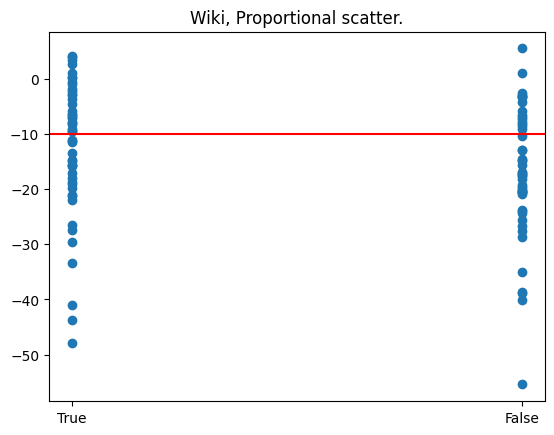

QQP Stats, Pos: 
Max: 4.535663604736328
Mean: -5.230272560119629
Min: -45.2017707824707
QQP Stats, Neg: 
Max: 6.444345474243164
Mean: -6.724311332702637
Min: -43.15762710571289
Num neg zeros: 0
[ -9.62480164   0.           0.          -0.93109894 -17.22692871
 -45.20177078   1.26288414  -2.85232925   0.           0.
  -3.05464935   0.          -8.03367996   0.           0.
 -30.69665527  -5.0352459    0.         -12.28624725   0.
  -6.59195709  -7.18319511 -10.49184608  -1.60263634  -4.01712799
   0.         -14.21550751  -2.38479042   0.          -3.69161224
   0.          -1.47567177   0.           4.5356636    2.43881226
  -4.97348022 -10.99340057 -17.30029297   0.           0.
  -8.30813599  -4.91565704  -0.54983139  -7.16981316   0.
  -3.25510979  -0.34514809  -9.20004272 -14.24475288  -1.89757156]
Num pos zeros: 16


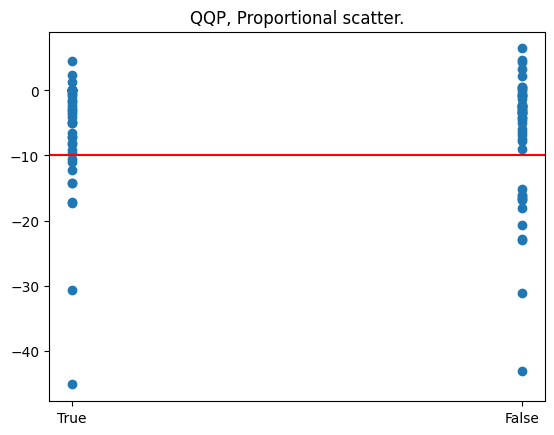

In [87]:
# Plotting line charts
# True paraphrase or False

category_wiki = ['True']*len(scores_wiki_pos) + ['False']*len(scores_wiki_neg)

combined_wiki = scores_wiki_pos + scores_wiki_neg
print("Stats, Pos: ")
print("Max: " + str(np.max(scores_wiki_pos)))
print("Mean: " + str(np.mean(scores_wiki_pos)))
print("Min: " + str(np.min(scores_wiki_pos)))
print("Stats, Neg: ")
print("Max: " + str(np.max(scores_wiki_neg)))
print("Mean: " + str(np.mean(scores_wiki_neg)))
print("Min: " + str(np.min(scores_wiki_neg)))

plt.scatter(category_wiki, combined_wiki)
plt.axhline(DIFF_THRESH, color='red')
plt.title("Wiki, Proportional scatter.")
plt.show()

category_qqp = ['True']*len(scores_qqp_pos) + ['False']*len(scores_qqp_neg)

combined_qqp = scores_qqp_pos + scores_qqp_neg
print("QQP Stats, Pos: ")
print("Max: " + str(np.max(scores_qqp_pos)))
print("Mean: " + str(np.mean(scores_qqp_pos)))
print("Min: " + str(np.min(scores_qqp_pos)))
print("QQP Stats, Neg: ")
print("Max: " + str(np.max(scores_qqp_neg)))
print("Mean: " + str(np.mean(scores_qqp_neg)))
print("Min: " + str(np.min(scores_qqp_neg)))

neg_scores = np.array(scores_prop_qqp_neg)
print("Num neg zeros: " + str(neg_scores.shape[0] - np.count_nonzero(neg_scores)))
# print(neg_scores)
# num_neg = np.where(neg_scores < 0.0)[0]
# # print(num_neg)
# print("Fract. Neg: " + str(num_neg.shape[0]/len(scores_prop_qqp_neg)))

pos_scores = np.array(scores_qqp_pos)
print(pos_scores)

print("Num pos zeros: " + str(neg_scores.shape[0] - np.count_nonzero(pos_scores)))
# num_pos = np.where(pos_scores >= 0.0)[0]
# print("Fract. Pos: " + str(num_pos.shape[0]/len(scores_prop_qqp_pos)))

plt.scatter(category_qqp, combined_qqp)
plt.axhline(DIFF_THRESH, color='red')
plt.title("QQP, Proportional scatter.")
plt.show()

In [ ]:
# TODO:
# Fabrizio: Did other works beat PAWS
# Get the best prompt/approach (for accuracy) & attack!
# Ensemble of prompts?
# Ensemble of perplexities (Expensive!)


# Plotting
plotrange =[6e-35, 10e-15]
# plt.hist(scores_positive, bins=100, range=plotrange)
# plt.hist(scores_negative, bins=50, range=[6e-35, 10e-20])
# plt.show()

# Difficult to visualize. 

# find a "pivot" threshold...

def get_pivot_threshold(positives, negatives, specificity, high_positive=True):
    # TODO: Implement case where high_positive=False
    # Negative tasks.
    positive_sorted = sorted(positives)
    negatives_sorted = sorted(negatives)

    if high_positive:
        negatives_pos = int(specificity * (len(negatives_sorted)-1))
    else:
        negatives_pos = int((1.0 - specificity) * (len(negatives_sorted)-1))

    threshold = negatives_sorted[negatives_pos]

    # For this threshold value, What would our sensitivity be?
    # This implements a binary search.
    search_idx = np.searchsorted(positive_sorted, [threshold], side='left', sorter=None)

    if high_positive:
        # Determine sensitivity
        return_sensitivity = (len(positive_sorted) - (search_idx[0] + 1)) / len(positive_sorted)

        return_specificity= (negatives_pos + 1) / len(negatives_sorted)
    else:
        return_specificity = (len(negatives_sorted) - (negatives_pos + 1)) / len(negatives_sorted)

        return_sensitivity = (search_idx[0] + 1) / len(positive_sorted)

    return (threshold, return_sensitivity, return_specificity)


print("WIKI STATS:")
# print("Thresholding for 0.9 specificity: ")
# thresh, sens, spec = get_pivot_threshold(scores_positive_wiki, scores_negative_wiki, 0.9, high_positive=True)
# print("Threshold: " + str(thresh) + "; Sensitivity: " + str(sens) + "; Specificity: " + str(spec))

print("Thresholding for 0.8 specificity: ")
thresh, sens, spec = get_pivot_threshold(scores_positive_wiki, scores_negative_wiki, 0.8, high_positive=True)
print("Threshold: " + str(thresh) + "; Sensitivity: " + str(sens) + "; Specificity: " + str(spec))

# print("Thresholding for 0.6 specificity: ")
# thresh, sens, spec = get_pivot_threshold(scores_positive_wiki, scores_negative_wiki, 0.6, high_positive=True)
# print("Threshold: " + str(thresh) + "; Sensitivity: " + str(sens) + "; Specificity: " + str(spec))

# print("Thresholding for 0.5 specificity: ")
# thresh, sens, spec = get_pivot_threshold(scores_positive_wiki, scores_negative_wiki, 0.5, high_positive=True)
# print("Threshold: " + str(thresh) + "; Sensitivity: " + str(sens) + "; Specificity: " + str(spec))

print("")

print("QQP STATS:")
# print("Thresholding for 0.9 specificity: ")
# thresh, sens, spec = get_pivot_threshold(scores_positive, scores_negative, 0.9, high_positive=True)
# print("Threshold: " + str(thresh) + "; Sensitivity: " + str(sens) + "; Specificity: " + str(spec))

print("Thresholding for 0.8 specificity: ")
thresh, sens, spec = get_pivot_threshold(scores_positive, scores_negative, 0.8, high_positive=True)
print("Threshold: " + str(thresh) + "; Sensitivity: " + str(sens) + "; Specificity: " + str(spec))

# print("Thresholding for 0.6 specificity: ")
# thresh, sens, spec = get_pivot_threshold(scores_positive, scores_negative, 0.6, high_positive=True)
# print("Threshold: " + str(thresh) + "; Sensitivity: " + str(sens) + "; Specificity: " + str(spec))

# print("Thresholding for 0.5 specificity: ")
# thresh, sens, spec = get_pivot_threshold(scores_positive, scores_negative, 0.5, high_positive=True)
# print("Threshold: " + str(thresh) + "; Sensitivity: " + str(sens) + "; Specificity: " + str(spec))



WIKI STATS:
Thresholding for 0.8 specificity: 
Threshold: 1.0530812333264805e-13; Sensitivity: 0.52; Specificity: 0.8

QQP STATS:
Thresholding for 0.8 specificity: 
Threshold: 4.336172991715103e-15; Sensitivity: 0.35; Specificity: 0.8


-First results - with basic rewriting task.
-Wiki distribution postive/negative is insanely close; determining difference is likely difficult.
-qqp a bit better. Need to chart out distribution.

Evaluating PAWS Wiki subsample
Eval results for PAWS Wiki subsample: 
Positive: min|mean|max: 3.06437883064988e-21|1.210064403472358e-07|3.379111603862839e-06
Negative: min|mean|max: 1.2581402729559316e-32|1.0390996079658279e-07|5.192478056414984e-06

Evaluating PAWS qqp subsample
Eval results for PAWS qqp subsample: 
Positive: min|mean|max: 7.041489165839472e-32|6.598129138963805e-10|3.2983027864474934e-08
Negative: min|mean|max: 6.569204261822275e-35|5.1491424027976954e-15|1.1752151172789854e-13

-Rerun, more stats.
Eval results for PAWS Wiki subsample: 
Positive: min|mean|max: 6.124804814987773e-25|7.40023710988744e-08|3.020819804078201e-06
Negative: min|mean|max: 1.3098722818430613e-36|1.0111780982519246e-09|4.212215998222746e-08
Evaluating PAWS qqp subsample
Eval results for PAWS qqp subsample: 
Positive: min|mean|max: 2.2166131472259967e-39|3.8332829024419694e-13|6.428116719470189e-12
Negative: min|mean|max: 3.84210989781837e-33|1.2843283175366501e-11|6.109925898556412e-10

WIKI STATS:
Thresholding for 0.9 specificity: 
Threshold: 3.3998563513104596e-12; Sensitivity: 0.36; Specificity: 0.9
Thresholding for 0.8 specificity: 
Threshold: 3.4453139668468025e-13; Sensitivity: 0.42; Specificity: 0.8
Thresholding for 0.6 specificity: 
Threshold: 1.147507648932683e-18; Sensitivity: 0.84; Specificity: 0.6
Thresholding for 0.5 specificity: 
Threshold: 3.059703604212143e-19; Sensitivity: 0.86; Specificity: 0.5

QQP STATS:
Thresholding for 0.9 specificity: 
Threshold: 5.437079755063294e-14; Sensitivity: 0.3; Specificity: 0.9
Thresholding for 0.8 specificity: 
Threshold: 1.367140928900713e-15; Sensitivity: 0.56; Specificity: 0.8
Thresholding for 0.6 specificity: 
Threshold: 4.651309376279579e-17; Sensitivity: 0.64; Specificity: 0.6
Thresholding for 0.5 specificity: 
Threshold: 3.773633368136887e-19; Sensitivity: 0.74; Specificity: 0.5

-Rerun 2. Cutting down to just 0.8 specificity. See if the threshold varies.
-It varies hugely for both qqp and wiki! Indicates sparse population of numbers?
-2:45 mins run.

Eval results for PAWS Wiki subsample: 
Positive: min|mean|max: 7.073887722660847e-29|1.1784631315639927e-08|3.707670259700535e-07
Negative: min|mean|max: 1.2131040805659941e-41|2.3511698643980347e-10|1.1416544154485564e-08
Evaluating PAWS qqp subsample
Eval results for PAWS qqp subsample: 
Positive: min|mean|max: 2.9528785434640494e-32|7.010876841758163e-12|3.2964200813445643e-10
Negative: min|mean|max: 6.409253871454377e-38|1.3158636739116692e-10|5.450550233376816e-09

WIKI STATS:
Thresholding for 0.8 specificity: 
Threshold: 5.360849076799365e-15; Sensitivity: 0.54; Specificity: 0.8

QQP STATS:
Thresholding for 0.8 specificity: 
Threshold: 1.7024831189858178e-17; Sensitivity: 0.6; Specificity: 0.8

-Big run, many samples.


In [ ]:
# Breaking evaluation into two parts; code draft
# Function Defs
def eval_q_segmented(pipeline, q1, q2):
    # Segment reasoning steps and answer parsing, so that we deal with parse failures more easily.

    # Original
    # verify_prompt = ("Do the following two sentences in quotes have the same meaning? Please explain your answer step by step, and "
    #             "then state either \"yes.\" or \"no.\" at the end of your answer."
    #         "\nSentence 1: '{q1}'"
    #         "\nSentence 2: '{q2}'\n")
    
    steps_prompt = ("I am trying to determine if the following sentences in quotes have the same meaning."
                    " Please provide me some reasoning steps that can help me determine if they mean the same thing."
            "\nSentence 1: '{q1}'"
            "\nSentence 2: '{q2}'\n")

    answer_prompt = ("Based on the previous steps, do Sentence 1 and Sentence 2 share the same meaning?"
                     " Please state either \"yes.\" or \"no.\" at the end of your response to indicate your answer.")

    steps_msgs = [{"role": "user", "content": steps_prompt.format(q1=q1, q2=q2)}]

    steps_prompt = pipeline.tokenizer.apply_chat_template(steps_msgs, tokenize=False, add_generation_prompt=True)

    with torch.no_grad():
        encoded_steps_request = pipeline.tokenizer(steps_prompt, return_tensors="pt",
                                            padding=False)  # Keeping padding off for now.
        
        # Put on proper device?
        # Inspiration: https://discuss.huggingface.co/t/device-map-auto-with-error-expected-all-tensors-to-be-on-the-same-device/31938/6
        encoded_steps_request.to(DEVICE_STR)

        steps_output = pipeline.model.generate(**encoded_steps_request, do_sample=True, temperature=GEN_TEMP,
                                                max_new_tokens=MAX_NEW_TOKENS,
                                                return_dict_in_generate=True, output_scores=True, output_logits=True,
                                                pad_token_id=pipeline.tokenizer.eos_token_id)

        # generated_output = generated_output.sequences[0][-MAX_NEW_TOKENS:]
        # Only get the newly generated tokens.
        steps_output = steps_output.sequences[0][encoded_steps_request['input_ids'].shape[1]:]


        # Keep tensor memory clear!
        del encoded_steps_request
        
    # Steps that the model invented.
    model_steps = pipeline.tokenizer.decode(steps_output)

    # Trying assistant role for now, but curious if the user role makes sense.
    answer_msgs = [{"role": "user", "content": steps_prompt.format(q1=q1, q2=q2)}, {"role": "assistant", "content": model_steps}]
    answer_prompt = pipeline.tokenizer.apply_chat_template(answer_msgs, tokenize=False, add_generation_prompt=True)

    # We'll separately try to parse for an answer now.

    successful_parse = False
    fail_count = 0
    while not successful_parse:

        print("Model Answer Prompt~~~~~~~~~~~~~~")
        print(prompt)

        answer_request = pipeline.tokenizer(answer_prompt, return_tensors="pt",
                                                    padding=False)  # Keeping padding off for now.

        # No gradients!
        with torch.no_grad():
            # Put on proper device?
            # Inspiration: https://discuss.huggingface.co/t/device-map-auto-with-error-expected-all-tensors-to-be-on-the-same-device/31938/6
            answer_request.to(DEVICE_STR)

            generated_output = pipeline.model.generate(**answer_request do_sample=True, temperature=GEN_TEMP,
                                                    max_new_tokens=MAX_NEW_TOKENS,
                                                    return_dict_in_generate=True, output_scores=True, output_logits=True,
                                                    pad_token_id=pipeline.tokenizer.eos_token_id)

            # generated_output = generated_output.sequences[0][-MAX_NEW_TOKENS:]
            generated_output = generated_output.sequences[0][encoded_verify_request['input_ids'].shape[1]:]

            

            # Detokenize, convert to lowercase.
            generated_output = pipeline.tokenizer.decode(generated_output).lower()

            # Keep tensor memory clear!
            del answer_request

        print("Model answer Response~~~~~~~~~~~~~~")
        print(generated_output)

        if re.search(re.escape("yes.<|eot_id|>") + "$", generated_output):  # Begin is "^yes"
            # yes
            print("Parsed yes")
            return True
        elif re.search(re.escape("no.<|eot_id|>") + "$", generated_output):  # Begin is "^no"
            # no
            print("Parsed no")
            return False

        else:
            fail_count += 1
            print("Response validation failure. Fail count: " + str(fail_count))
            # print("Failing Validation response:")
            # print(generated_output)
            if fail_count > PARSE_RETRIES:
                print("Could not generate a valid response!")
                return None